In [10]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path
import sys

sys.path.append(os.path.abspath(os.path.join(os.path.dirname(__file__), "..", "..")))

from src.visualization.visualize import (
    plot_scatterplot,
    plot_regplot,
    plot_lineplot,
    plot_kdeplot,
    plot_violinplot,
    plot_facetgrid,
    plot_piechart,
    plot_barplot,
    plot_boxplot,
    plot_countplot,
)

%matplotlib inline

plt.style.use("ggplot")

warnings.filterwarnings("ignore")

NameError: name '__file__' is not defined

In [11]:
csv_path = Path("../data/processed/processed_flight.csv")

flights = pd.read_csv(csv_path)
print(flights.shape)

(10387, 10)


In [12]:
flights.head()

,Airline,Date_of_Journey,Source,Destination,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,2019-03-24,Banglore,New Delhi,22:20:00,01:10:00,170,0,No info,3897
1,Air India,2019-05-01,Kolkata,Banglore,05:50:00,13:15:00,445,2,No info,7662
2,Jet Airways,2019-06-09,Delhi,Cochin,09:25:00,04:25:00,1140,2,No info,13882
3,IndiGo,2019-05-12,Kolkata,Banglore,18:05:00,23:30:00,325,1,No info,6218
4,IndiGo,2019-03-01,Banglore,New Delhi,16:50:00,21:35:00,285,1,No info,13302


In [13]:
flights.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10387 entries, 0 to 10386
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10387 non-null  object
 1   Date_of_Journey  10387 non-null  object
 2   Source           10387 non-null  object
 3   Destination      10387 non-null  object
 4   Dep_Time         10387 non-null  object
 5   Arrival_Time     10387 non-null  object
 6   Duration         10387 non-null  int64 
 7   Total_Stops      10387 non-null  int64 
 8   Additional_Info  10387 non-null  object
 9   Price            10387 non-null  int64 
dtypes: int64(3), object(7)
memory usage: 811.6+ KB


In [14]:
flights.describe()

,Duration,Total_Stops,Price
count,10387.00000,10387.000000,10387.000000
mean,618.03023,0.792337,9000.783094
std,482.80541,0.651552,4621.264354
min,5.00000,0.000000,1759.000000
25%,170.00000,0.000000,5201.000000
50%,500.00000,1.000000,8146.000000
75%,900.00000,1.000000,12319.000000
max,2000.00000,4.000000,79512.000000


In [15]:
print("Missing values in each column:")
print(flights.isnull().sum())

Missing values in each column:
Airline            0
Date_of_Journey    0
Source             0
Destination        0
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        0
Additional_Info    0
Price              0
dtype: int64


Univariate analysis

In [ ]:
print(f'soruce: {flights["Source"].unique().tolist()}')
print(f'Additional_Info: {flights["Additional_Info"].unique().tolist()}')
print(f'Airline: {flights["Airline"].unique().tolist()}')
print(f'Destination: {flights["Destination"].unique().tolist()}')

soruce: ['Banglore', 'Kolkata', 'Delhi', 'Chennai', 'Mumbai']
Additional_Info: ['No info', 'In-flight meal not included', 'No check-in baggage included', 'Other', '1 Long layover']
Airline: ['IndiGo', 'Air India', 'Jet Airways', 'SpiceJet', 'Multiple carriers', 'GoAir', 'Vistara', 'Air Asia', 'Other']
Destination: ['New Delhi', 'Banglore', 'Cochin', 'Kolkata', 'Delhi', 'Hyderabad']


In [15]:
flights["Additional_Info"].value_counts()

Additional_Info
No info                         8118
In-flight meal not included     1918
No check-in baggage included     318
1 Long layover                    19
Change airports                    7
Business class                     4
1 Short layover                    1
Red-eye flight                     1
2 Long layover                     1
Name: count, dtype: int64

In [16]:
flights["Airline"].value_counts()

Airline
Jet Airways          3675
IndiGo               2043
Air India            1644
Multiple carriers    1209
SpiceJet              815
Vistara               481
Air Asia              319
GoAir                 194
Jet Airways             6
Trujet                  1
Name: count, dtype: int64

In [17]:
flights["Source"].value_counts()

Source
Delhi       4287
Kolkata     2854
Banglore    2170
Mumbai       695
Chennai      381
Name: count, dtype: int64

In [12]:
flights["Destination"].value_counts()

Cochin       4345
Banglore     2860
Delhi        1265
New Delhi     914
Hyderabad     697
Kolkata       381
Name: Destination, dtype: int64

<Figure size 500x300 with 0 Axes>

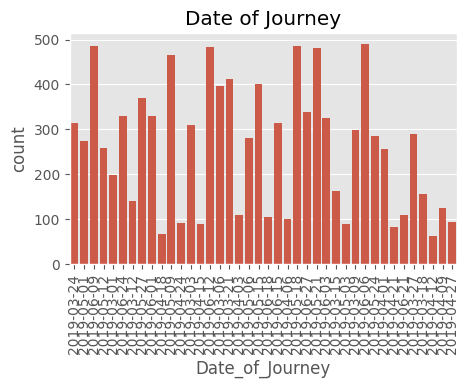

In [13]:
# date of journey analysis
plt.figure(figsize=(5, 3))
plot_countplot(data=flights, x="Date_of_Journey", title="Date of Journey")
plt.show()

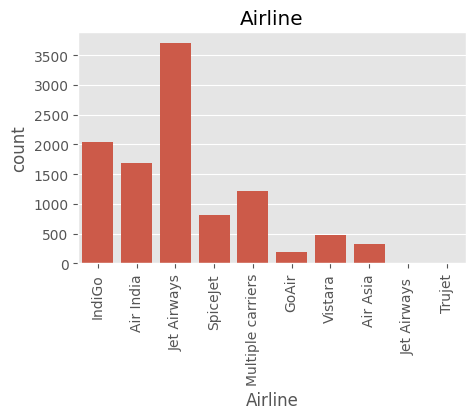

In [14]:
# Airline analysis
plot_countplot(data=flights, x="Airline", title="Airline")

Boxplot for Price to identify outliers:


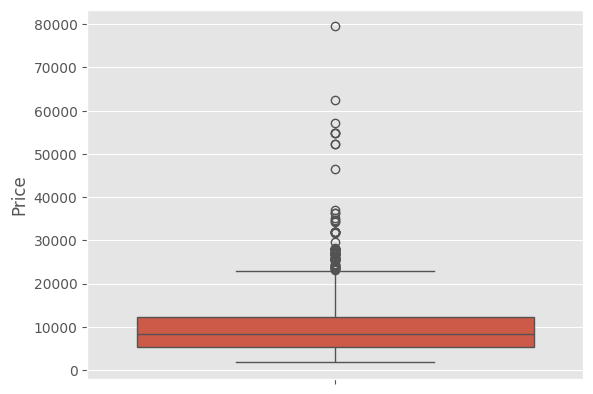

In [15]:
print("Boxplot for Price to identify outliers:")
sns.boxplot(flights["Price"])
plt.show()

<Axes: xlabel='count', ylabel='Source'>

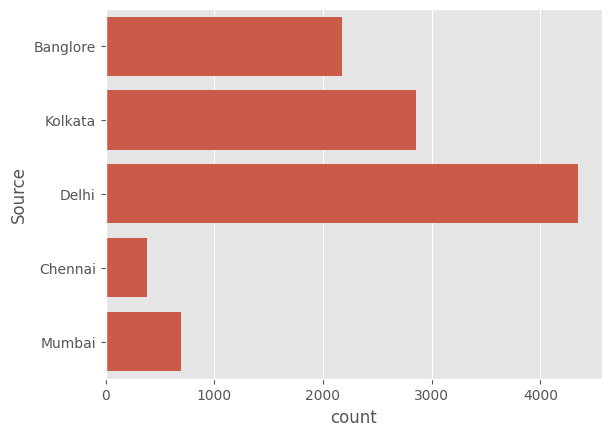

In [16]:
# source analysis
sns.countplot(flights["Source"])

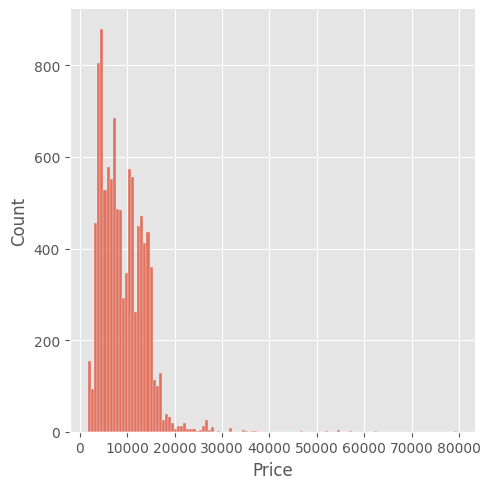

In [17]:
sns.displot(flights["Price"])

<Axes: xlabel='Price', ylabel='Count'>

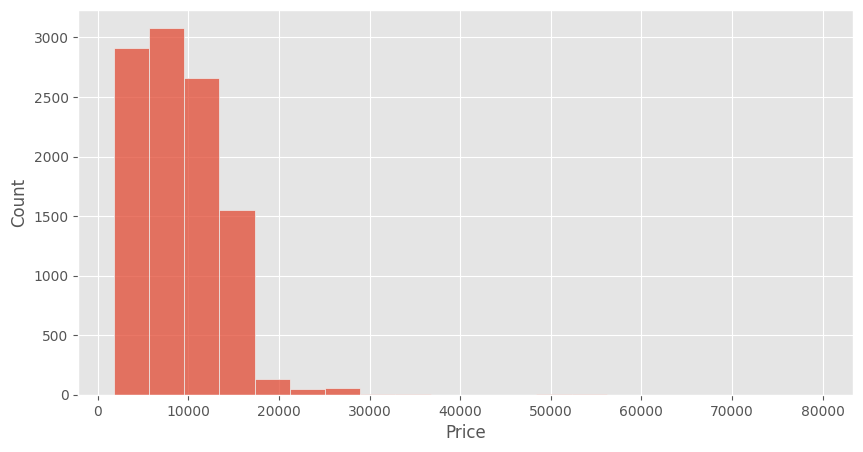

In [18]:
plt.figure(figsize=(10, 5))
sns.histplot(flights["Price"], bins=20)

Bivariate analysis

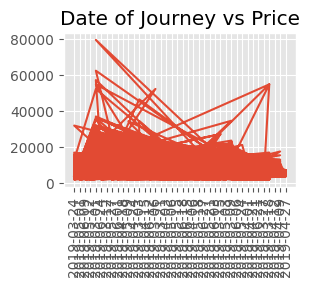

In [19]:
plot_lineplot(
    data=flights, x="Date_of_Journey", y="Price", title="Date of Journey vs Price"
)

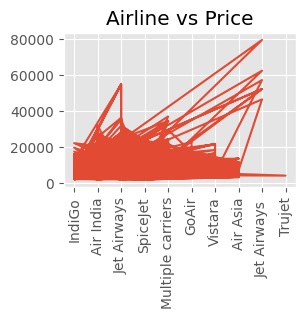

In [20]:
plot_lineplot(data=flights, x="Airline", y="Price", title="Airline vs Price")

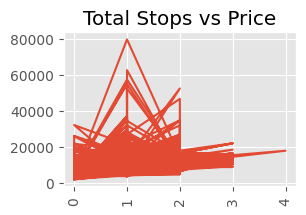

In [21]:
plot_lineplot(data=flights, x="Total_Stops", y="Price", title="Total Stops vs Price")

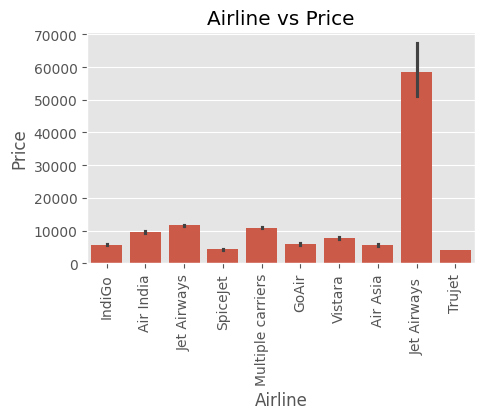

In [22]:
# airline vs price
plot_barplot(data=flights, x="Airline", y="Price", title="Airline vs Price")

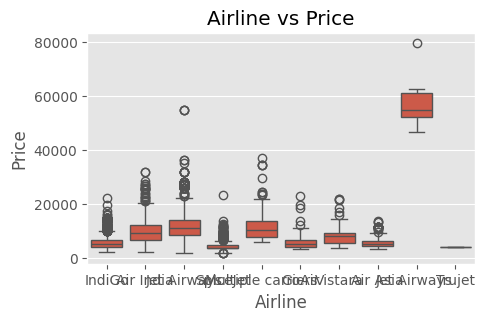

In [23]:
plot_boxplot(data=flights, x="Airline", y="Price", title="Airline vs Price")

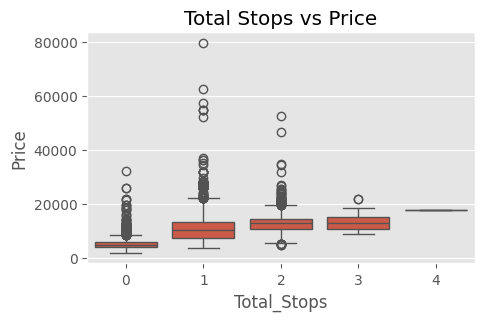

In [24]:
plot_boxplot(data=flights, x="Total_Stops", y="Price", title="Total Stops vs Price")

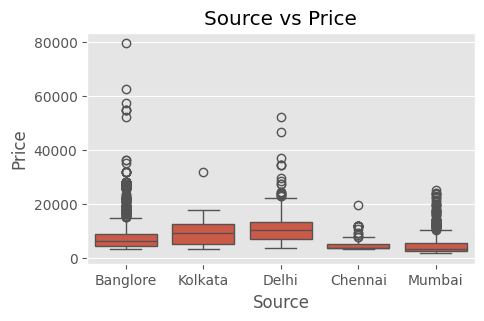

In [25]:
plot_boxplot(data=flights, x="Source", y="Price", title="Source vs Price")

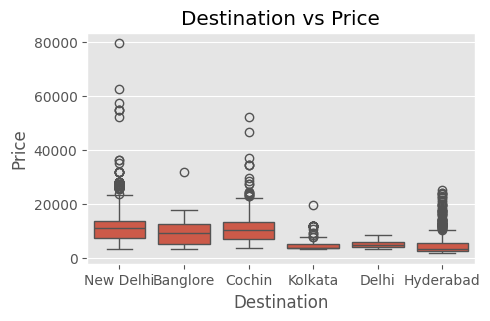

In [26]:
plot_boxplot(data=flights, x="Destination", y="Price", title="Destination vs Price")

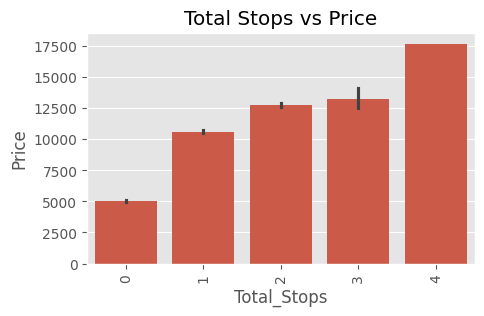

In [27]:
# total stops vs price
plot_barplot(data=flights, x="Total_Stops", y="Price", title="Total Stops vs Price")

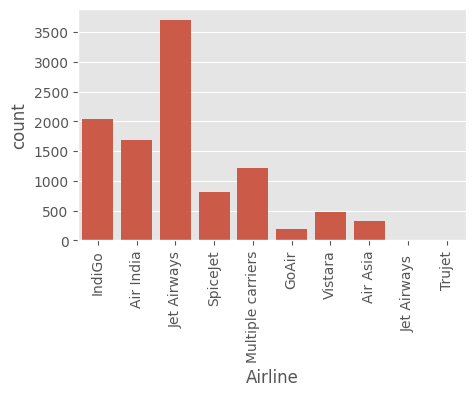

In [28]:
plot_countplot(x="Airline", data=flights)

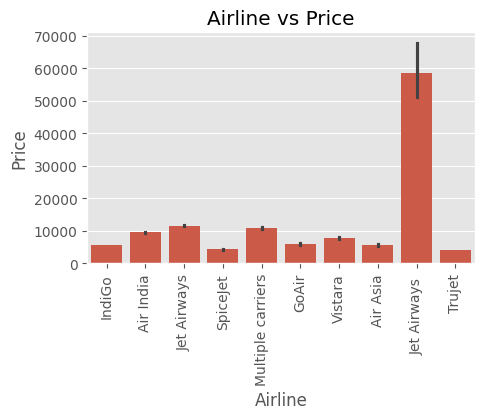

In [29]:
plot_barplot(data=flights, x="Airline", y="Price", title="Airline vs Price")

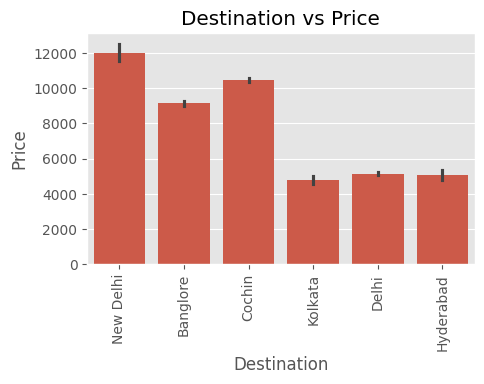

In [30]:
plot_barplot(x="Destination", y="Price", data=flights, title="Destination vs Price")

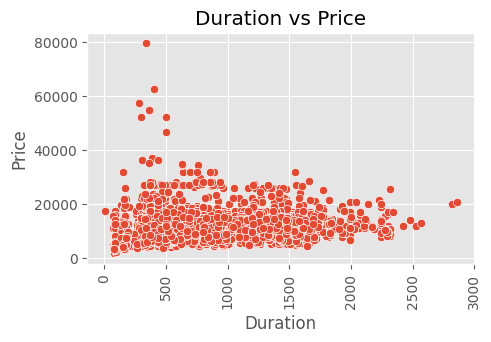

In [31]:
plot_scatterplot(data=flights, x="Duration", y="Price", title="Duration vs Price")

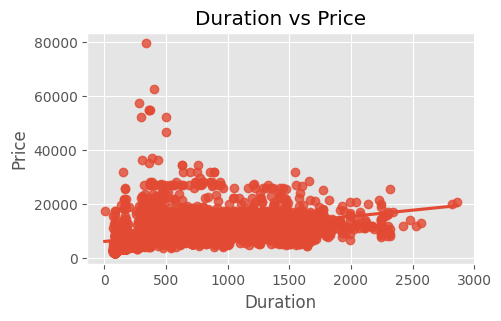

In [32]:
plot_regplot(data=flights, x="Duration", y="Price", title="Duration vs Price")

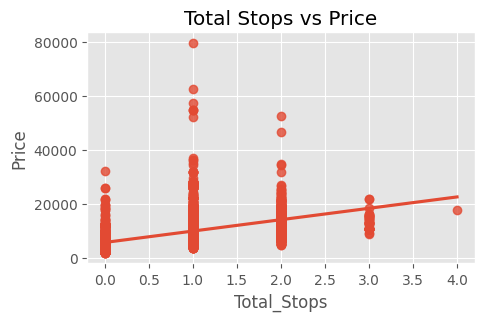

In [33]:
plot_regplot(data=flights, x="Total_Stops", y="Price", title="Total Stops vs Price")

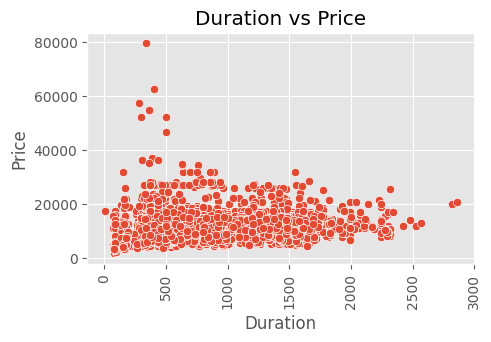

In [34]:
plot_scatterplot(x="Duration", y="Price", data=flights, title="Duration vs Price")

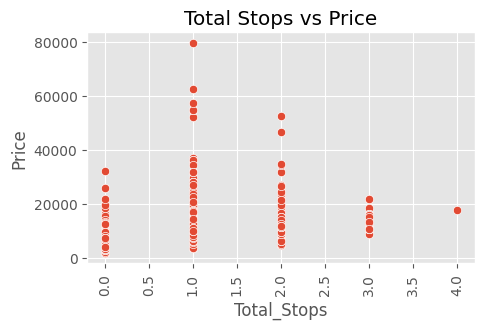

In [35]:
plot_scatterplot(data=flights, x="Total_Stops", y="Price", title="Total Stops vs Price")

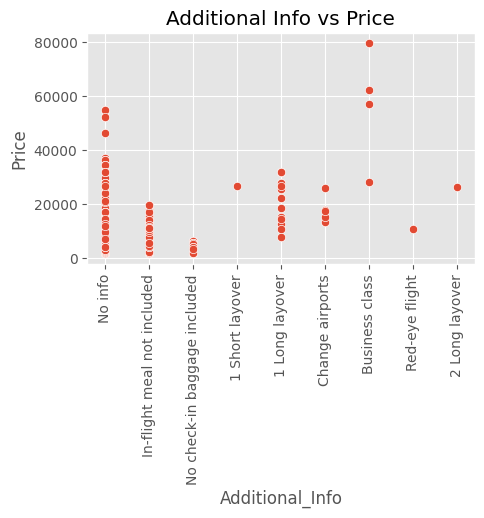

In [36]:
plot_scatterplot(
    x="Additional_Info", y="Price", data=flights, title="Additional Info vs Price"
)

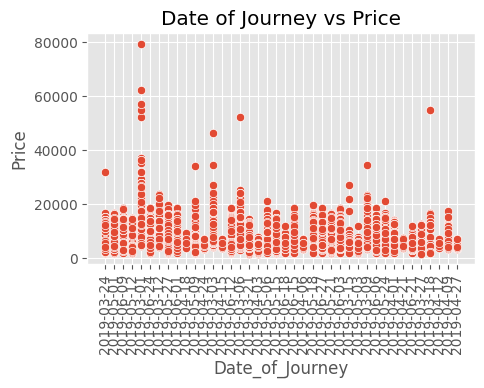

In [37]:
plot_scatterplot(
    x="Date_of_Journey", y="Price", data=flights, title="Date of Journey vs Price"
)

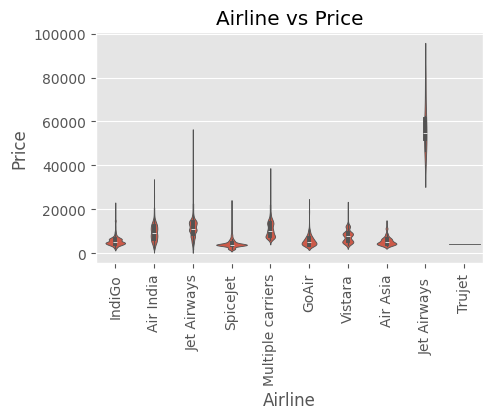

In [38]:
plot_violinplot(x="Airline", y="Price", data=flights, title="Airline vs Price")

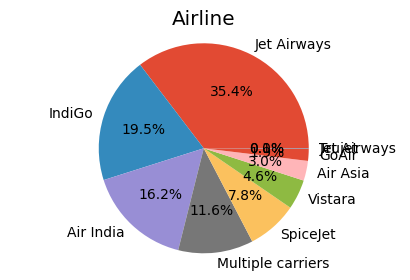

In [39]:
# Pie Chart
plot_piechart(data=flights, column="Airline", title="Airline")

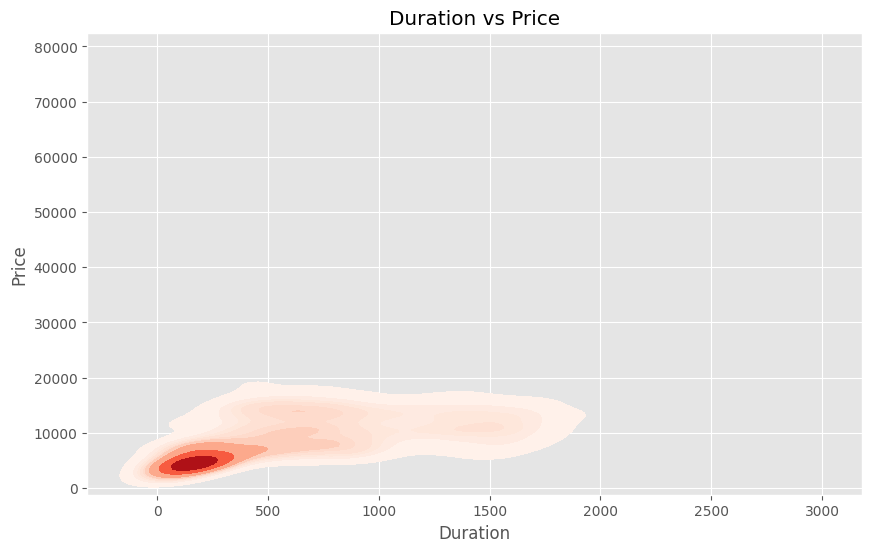

In [40]:
plot_kdeplot(data=flights, x="Duration", y="Price", title="Duration vs Price")

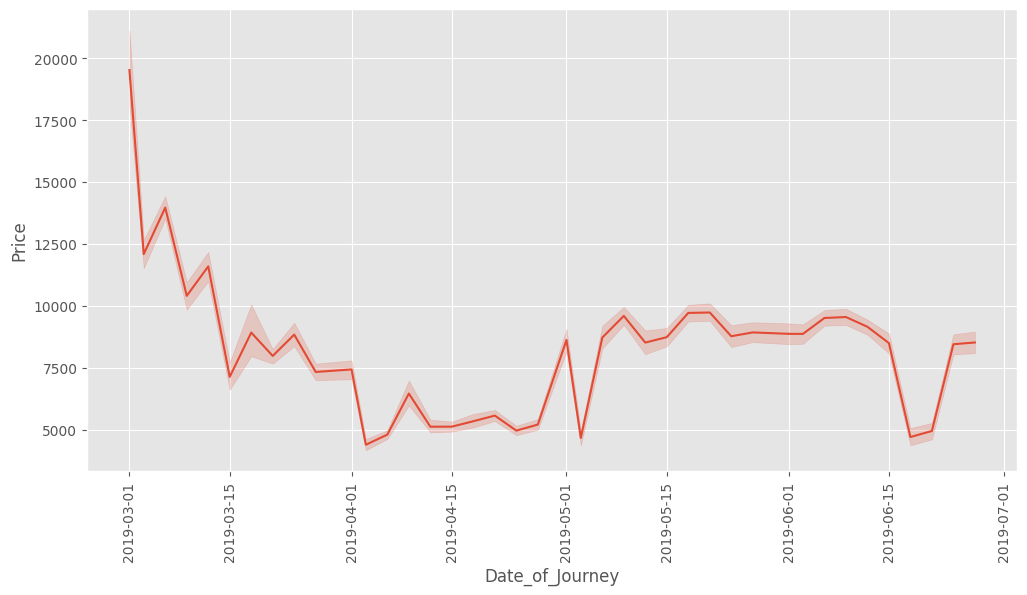

In [41]:
# Time Series Plot
flights["Date_of_Journey"] = pd.to_datetime(flights["Date_of_Journey"])
plt.figure(figsize=(12, 6))
sns.lineplot(x="Date_of_Journey", y="Price", data=flights)
plt.xticks(rotation=90)
plt.show()

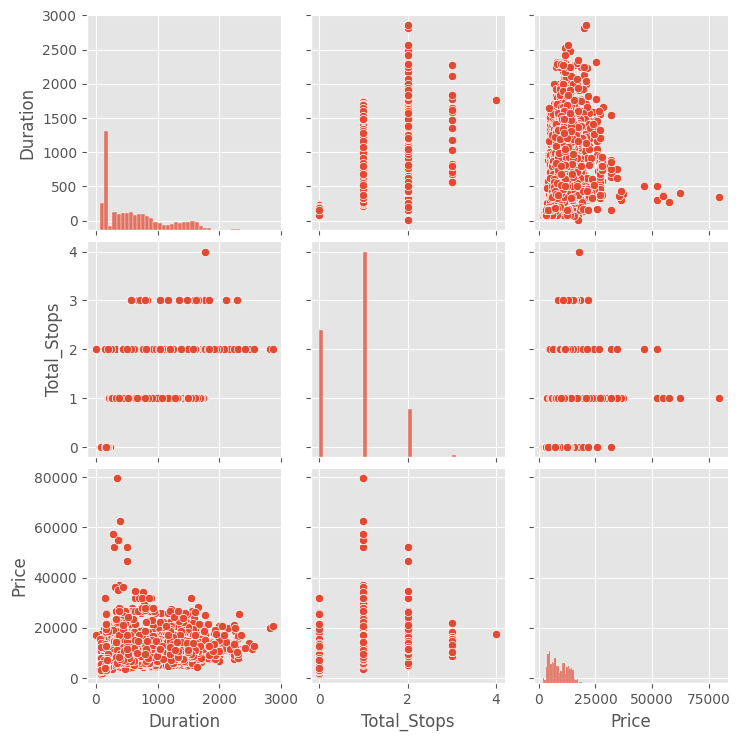

In [42]:
sns.pairplot(flights)

<Figure size 1200x800 with 0 Axes>

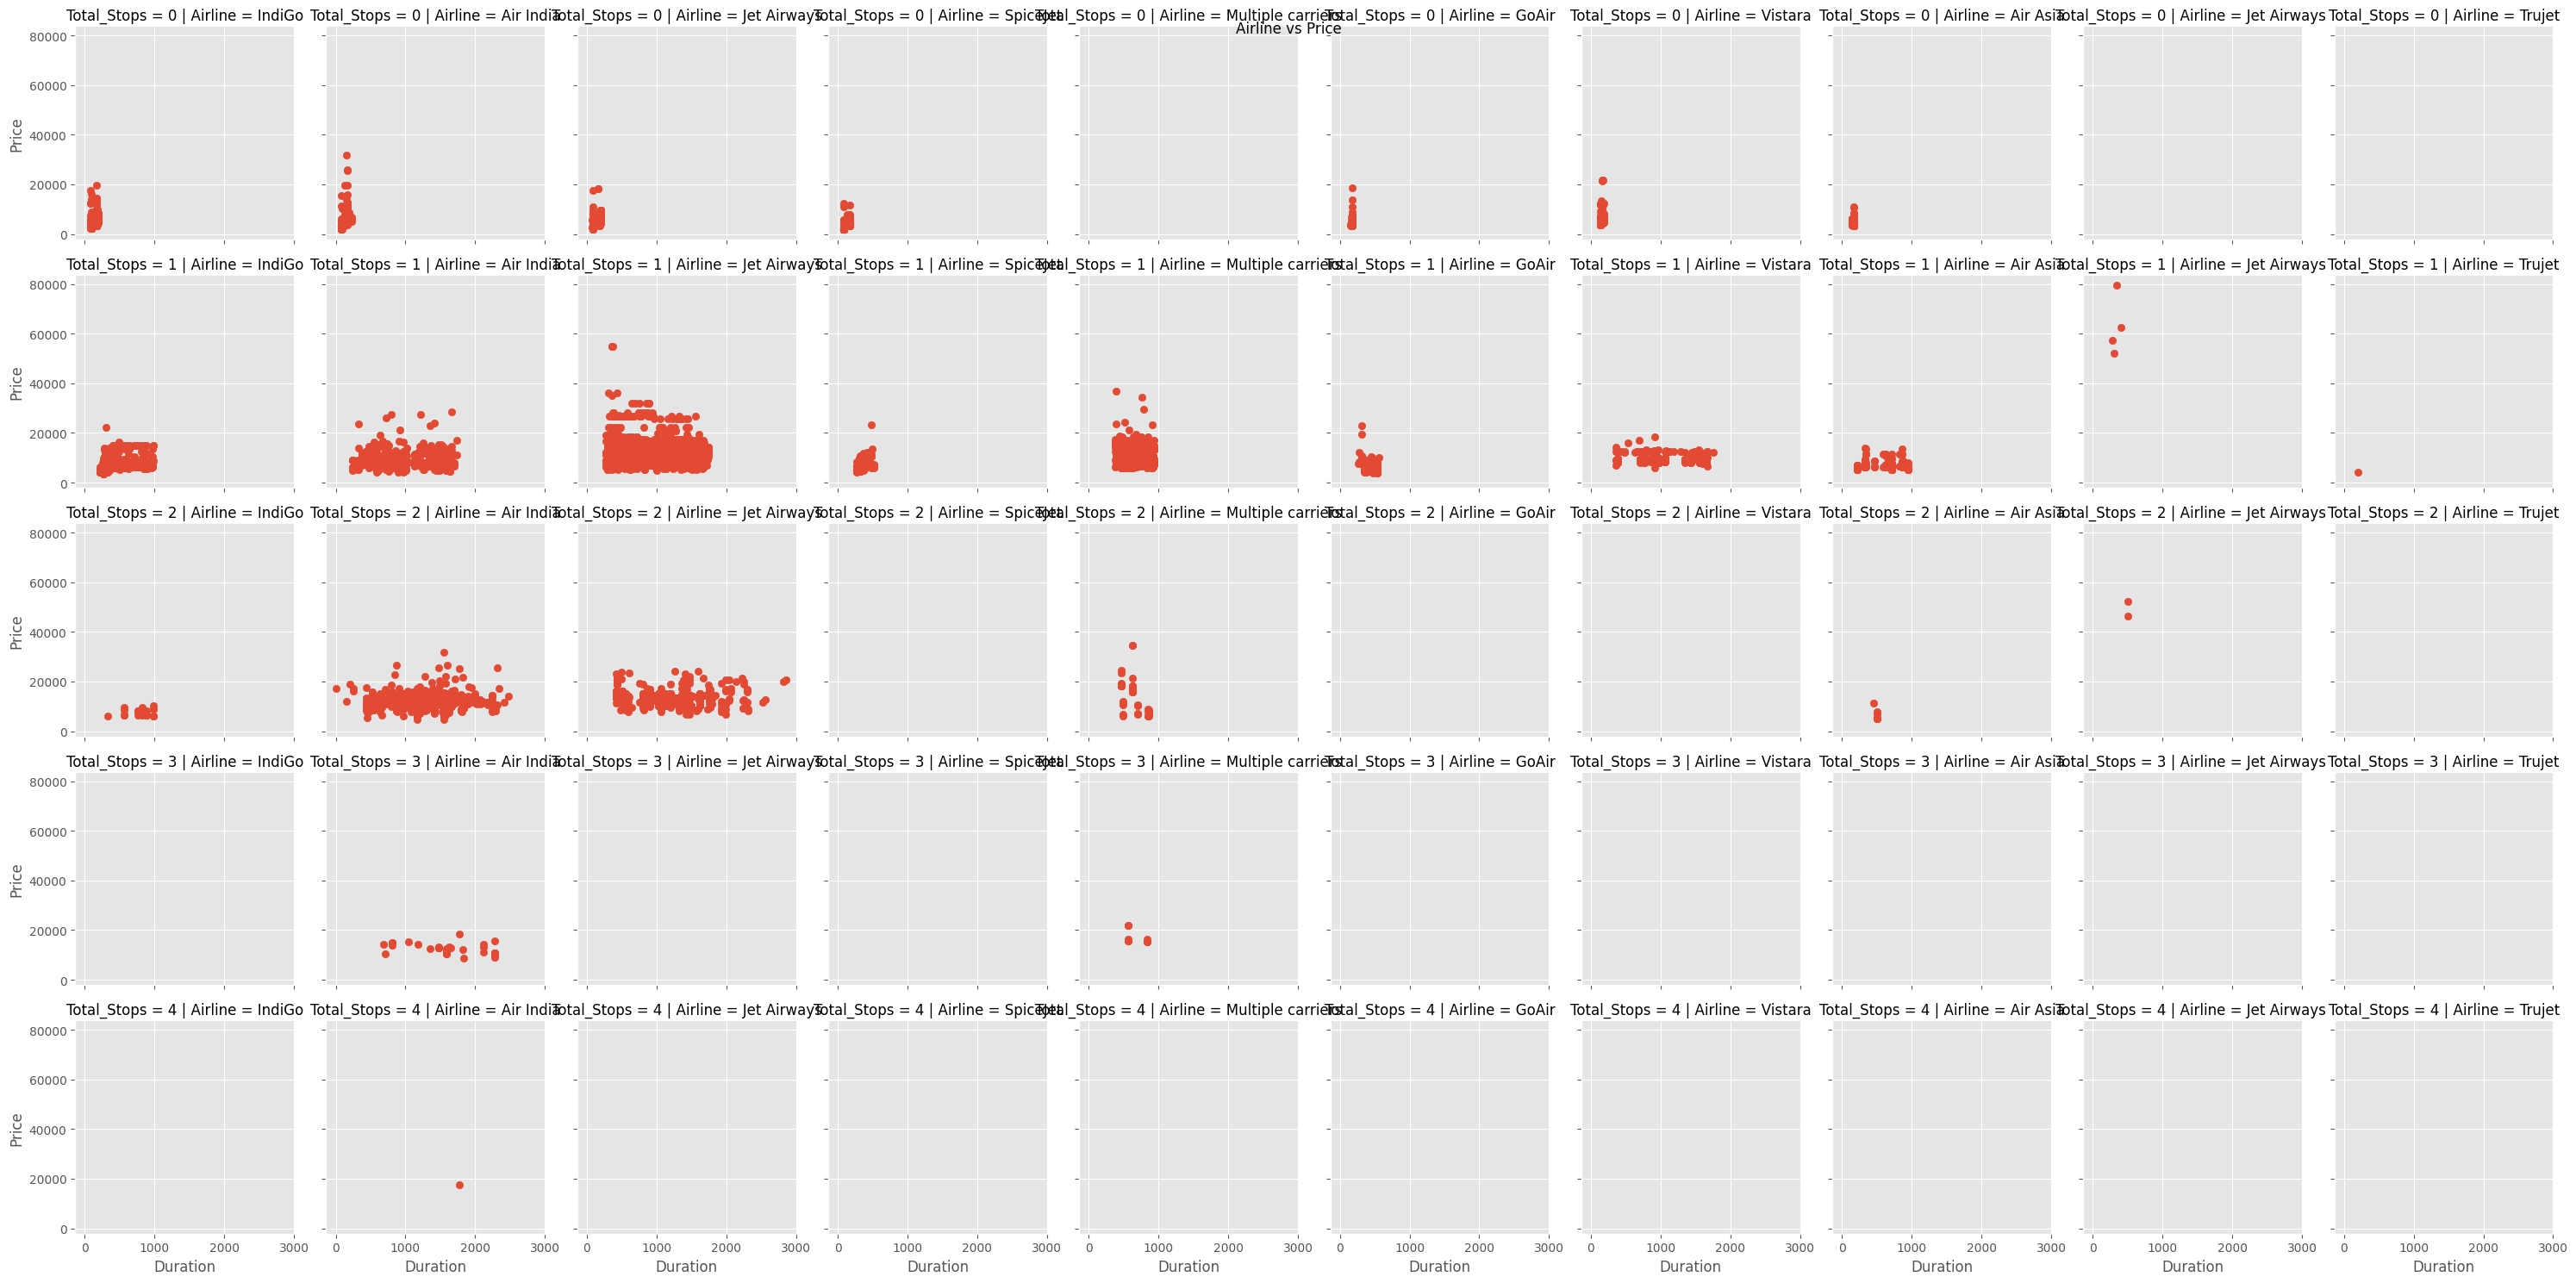

In [43]:
plot_facetgrid(
    data=flights,
    x="Duration",
    y="Price",
    col="Airline",
    row="Total_Stops",
    title="Airline vs Price",
)